# Zhang 2018 recursive introns — overlap with nascent LCL junction classifications

Intersect `nascent_LCL.classification_recursive.bed.gz` against:
- `Zhang_2018_full_introns.sorted.bed.gz`
- `Zhang_2018_partial_introns.sorted.bed.gz`

at three overlap thresholds (perfect, 0.99, 0.95), then examine Coding classification
and splice-site sharing between partial and full intron pairs.

In [14]:
import pybedtools
import pandas as pd
import numpy as np
import gzip
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from io import StringIO

## 1. Load files

In [15]:
CLASSIF = "../code/resources/nascent_LCL.classification_recursive.bed.gz"
FULL    = "../code/resources/Zhang_2018_full_introns.sorted.bed.gz"
PARTIAL = "../code/resources/Zhang_2018_partial_introns.sorted.bed.gz"

classif_cols = ["chrom","start","end","gene","dot","strand","Annot","Coding","UTR","GencodePC"]
full_cols    = ["chrom","start","end","gene","score","strand","partial1","partial2"]
partial_cols = ["chrom","start","end","gene","score","strand","full_intron"]

def read_bed_gz(path, cols):
    with gzip.open(path, "rt") as f:
        return pd.read_csv(f, sep="\t", header=None, names=cols, dtype=str)

df_classif  = read_bed_gz(CLASSIF, classif_cols)
df_full_ref = read_bed_gz(FULL,    full_cols)
df_part_ref = read_bed_gz(PARTIAL, partial_cols)

print(f"Classification entries : {len(df_classif):,}")
print(f"Full introns           : {len(df_full_ref)}")
print(f"Partial introns        : {len(df_part_ref)}")
df_classif.head(3)

Classification entries : 836,516
Full introns           : 360
Partial introns        : 720


,chrom,start,end,gene,dot,strand,Annot,Coding,UTR,GencodePC
0,chr1,944800,945056,NOC2L,.,-,True,True,False,True
1,chr1,944800,945041,NOC2L,.,-,True,True,False,False
2,chr1,944819,945056,NOC2L,.,-,False,True,False,False


In [16]:
df_full_ref.head(3)

,chrom,start,end,gene,score,strand,partial1,partial2
0,chr1,14099683,14142921,PRDM2,12.954081,+,chr1:14099683-14108945,chr1:14108945-14142921
1,chr1,19712120,19746154,CAPZB,10.870653,-,chr1:19712120-19733027,chr1:19733027-19746154
2,chr1,26772923,26784281,DHDDS,5.152871,+,chr1:26772923-26781537,chr1:26781537-26784281


In [17]:
df_part_ref.head(3)

,chrom,start,end,gene,score,strand,full_intron
0,chr1,14099683,14108945,PRDM2,12.954081,+,chr1:14099683-14142921
1,chr1,14108945,14142921,PRDM2,12.954081,+,chr1:14099683-14142921
2,chr1,19712120,19733027,CAPZB,10.870653,-,chr1:19712120-19746154


## 2. Bedtools intersect at multiple overlap thresholds

Columns after `-wa -wb`:
- **Full** (8 cols) + classification (10 cols) = 18 total; `Coding` at index 15
- **Partial** (7 cols) + classification (10 cols) = 17 total; `Coding` at index 14

In [18]:
def intersect(query_path, classif_path, frac, query_cols, classif_cols):
    """Run bedtools intersect -f frac -F frac -wa -wb and return a DataFrame."""
    a = pybedtools.BedTool(query_path)
    b = pybedtools.BedTool(classif_path)
    hits = a.intersect(b, f=frac, F=frac, wa=True, wb=True)
    if len(hits) == 0:
        return pd.DataFrame(columns=query_cols + classif_cols)
    df = hits.to_dataframe(names=query_cols + classif_cols, dtype=str)
    return df

fracs  = [("perfect", 1.0), ("f0.99", 0.99), ("f0.95", 0.95)]
results = {}

full_hit_cols    = full_cols    + [f"c_{c}" if c in full_cols    else c for c in classif_cols]
partial_hit_cols = partial_cols + [f"c_{c}" if c in partial_cols else c for c in classif_cols]

# Rename to avoid collision
c_sfx = ["c_chrom","c_start","c_end","c_gene","c_dot","c_strand","Annot","Coding","UTR","GencodePC"]
full_hit_cols    = full_cols    + c_sfx
partial_hit_cols = partial_cols + c_sfx

for label, frac in fracs:
    results[(label, "Full")]    = intersect(FULL,    CLASSIF, frac, full_cols,    c_sfx)
    results[(label, "Partial")] = intersect(PARTIAL, CLASSIF, frac, partial_cols, c_sfx)
    print(f"{label}  Full={len(results[(label,'Full')])}  Partial={len(results[(label,'Partial')])}")

perfect  Full=3  Partial=3
f0.99  Full=14  Partial=7
f0.95  Full=23  Partial=19


f0.99  Full=14  Partial=7


f0.95  Full=23  Partial=19


## 3. Summary table: Coding=True rates

In [19]:
rows = []
for label, frac in fracs:
    for group in ("Full", "Partial"):
        df = results[(label, group)]
        n  = len(df)
        c  = (df["Coding"].str.strip() == "True").sum() if n else 0
        rows.append({"Overlap": label, "Group": group, "Total": n,
                     "Coding=True": c, "% Coding": round(100*c/n, 1) if n else 0.0})

summary = pd.DataFrame(rows)
summary

,Overlap,Group,Total,Coding=True,% Coding
0,perfect,Full,3,3,100.0
1,perfect,Partial,3,0,0.0
2,f0.99,Full,14,10,71.4
3,f0.99,Partial,7,1,14.3
4,f0.95,Full,23,13,56.5
5,f0.95,Partial,19,4,21.1


## 4. Perfect-overlap hits in detail

In [20]:
show = ["chrom","start","end","gene","strand","Annot","Coding","UTR","GencodePC"]

print("=== Full introns — perfect overlap ===")
df = results[("perfect", "Full")]
display(df[show + ["partial1","partial2"]].reset_index(drop=True))

print("\n=== Partial introns — perfect overlap ===")
df = results[("perfect", "Partial")]
display(df[show + ["full_intron"]].reset_index(drop=True))

=== Full introns — perfect overlap ===


,chrom,start,end,gene,strand,Annot,Coding,UTR,GencodePC,partial1,partial2
0,chr9,5929159,5944870,KIAA2026,-,True,True,False,True,chr9:5929159-5933881,chr9:5933881-5944870
1,chr9,6460791,6475390,UHRF2,+,True,True,False,True,chr9:6460791-6464552,chr9:6464552-6475390
2,chr9,6460791,6475390,UHRF2,+,True,True,False,True,chr9:6460791-6465743,chr9:6465743-6475390



=== Partial introns — perfect overlap ===


,chrom,start,end,gene,strand,Annot,Coding,UTR,GencodePC,full_intron
0,chr9,5933881,5944870,KIAA2026,-,True,False,False,False,chr9:5929159-5944870
1,chr9,6460791,6465743,UHRF2,+,False,False,False,False,chr9:6460791-6475390
2,chr9,6460791,6464552,UHRF2,+,False,False,False,False,chr9:6460791-6475390


## 5. Splice-site sharing: partial introns vs their parent full intron

For every partial intron that overlaps the classification bed (f0.95 pool),
look up all sibling partial introns that share the same parent full intron,
check for consecutive pairs (end of piece 1 == start of piece 2),
and compare Coding classification between partial pieces and the full intron.

In [21]:
df_p95 = results[("f0.95", "Partial")].copy()
df_f95 = results[("f0.95", "Full")].copy()

# Convert coords to int for sorting / comparison
for df in (df_p95, df_f95, df_part_ref, df_full_ref):
    df["start"] = df["start"].astype(int)
    df["end"]   = df["end"].astype(int)

records = []

for full_id, grp in df_p95.groupby("full_intron"):
    chrom_f, coords = full_id.split(":")
    s_f, e_f = (int(x) for x in coords.split("-"))

    # All sibling partial introns from source BED
    sibs = (df_part_ref[df_part_ref["full_intron"] == full_id]
            .sort_values(["chrom","start"])
            .reset_index(drop=True))

    # Identify consecutive pairs
    consecutive_pairs = []
    for i in range(len(sibs) - 1):
        r1, r2 = sibs.iloc[i], sibs.iloc[i+1]
        if r1["end"] == r2["start"]:
            consecutive_pairs.append((f"{r1['chrom']}:{r1['start']}-{r1['end']}",
                                      f"{r2['chrom']}:{r2['start']}-{r2['end']}"))

    # Full intron classification (check all thresholds)
    full_coding = full_annot = full_gencode = "N/A"
    for lbl in ("perfect", "f0.99", "f0.95"):
        tmp = results[(lbl, "Full")].copy()
        tmp["start"] = tmp["start"].astype(int)
        tmp["end"]   = tmp["end"].astype(int)
        mf = tmp[(tmp["chrom"]==chrom_f)&(tmp["start"]==s_f)&(tmp["end"]==e_f)]
        if not mf.empty:
            full_coding  = mf["Coding"].iloc[0]
            full_annot   = mf["Annot"].iloc[0]
            full_gencode = mf["GencodePC"].iloc[0]
            break

    for _, pr in grp.iterrows():
        records.append({
            "full_intron"       : full_id,
            "partial_coord"     : f"{pr['chrom']}:{pr['start']}-{pr['end']}",
            "gene"              : pr["gene"],
            "strand"            : pr["strand"],
            "n_sibs"            : len(sibs),
            "consecutive_pairs" : "; ".join(f"{a}|{b}" for a,b in consecutive_pairs),
            "partial_Annot"     : pr["Annot"],
            "partial_Coding"    : pr["Coding"],
            "partial_GencodePC" : pr["GencodePC"],
            "full_Annot"        : full_annot,
            "full_Coding"       : full_coding,
            "full_GencodePC"    : full_gencode,
            "coding_divergent"  : pr["Coding"] != full_coding,
        })

splice_df = pd.DataFrame(records)
splice_df

,full_intron,partial_coord,gene,strand,n_sibs,consecutive_pairs,partial_Annot,partial_Coding,partial_GencodePC,full_Annot,full_Coding,full_GencodePC,coding_divergent
0,chr11:78189729-78204108,chr11:78189729-78196552,NARS2,-,2,chr11:78189729-78196552|chr11:78196552-78204108,False,False,False,N/A,N/A,N/A,True
1,chr14:70795953-70842392,chr14:70795953-70839842,SYNJ2BP-COX16,-,2,chr14:70795953-70839842|chr14:70839842-70842392,False,False,False,N/A,N/A,N/A,True
2,chr18:12454482-12463349,chr18:12454482-12459927,SPIRE1,-,2,chr18:12454482-12459927|chr18:12459927-12463349,True,True,False,True,True,True,False
3,chr18:12454482-12463349,chr18:12459927-12463349,SPIRE1,-,2,chr18:12454482-12459927|chr18:12459927-12463349,True,True,False,True,True,True,False
4,chr18:9577189-9588086,chr18:9577189-9584764,PPP4R1,-,2,chr18:9577189-9584764|chr18:9584764-9588086,True,True,False,False,True,False,False
5,chr18:9577189-9588086,chr18:9584764-9588086,PPP4R1,-,2,chr18:9577189-9584764|chr18:9584764-9588086,False,False,False,False,True,False,True
6,chr18:9577189-9588086,chr18:9584764-9588086,PPP4R1,-,2,chr18:9577189-9584764|chr18:9584764-9588086,True,True,True,False,True,False,False
7,chr18:9577189-9588086,chr18:9584764-9588086,PPP4R1,-,2,chr18:9577189-9584764|chr18:9584764-9588086,False,False,False,False,True,False,True
8,chr3:14989413-15045382,chr3:14989413-15003915,NR2C2,+,2,chr3:14989413-15003915|chr3:15003915-15045382,False,False,False,N/A,N/A,N/A,True
9,chr6:151358253-151390170,chr6:151365898-151390170,MTHFD1L,+,2,chr6:151358253-151365898|chr6:151365898-151390170,False,False,False,N/A,N/A,N/A,True


### 5a. Cases with consecutive partial pairs

In [22]:
consec = splice_df[splice_df["consecutive_pairs"] != ""].copy()
print(f"{consec['full_intron'].nunique()} parent full introns have consecutive partial pairs")
consec[["full_intron","partial_coord","gene","partial_Coding","full_Coding",
        "partial_GencodePC","full_GencodePC","coding_divergent"]]

9 parent full introns have consecutive partial pairs


,full_intron,partial_coord,gene,partial_Coding,full_Coding,partial_GencodePC,full_GencodePC,coding_divergent
0,chr11:78189729-78204108,chr11:78189729-78196552,NARS2,False,N/A,False,N/A,True
1,chr14:70795953-70842392,chr14:70795953-70839842,SYNJ2BP-COX16,False,N/A,False,N/A,True
2,chr18:12454482-12463349,chr18:12454482-12459927,SPIRE1,True,True,False,True,False
3,chr18:12454482-12463349,chr18:12459927-12463349,SPIRE1,True,True,False,True,False
4,chr18:9577189-9588086,chr18:9577189-9584764,PPP4R1,True,True,False,False,False
5,chr18:9577189-9588086,chr18:9584764-9588086,PPP4R1,False,True,False,False,True
6,chr18:9577189-9588086,chr18:9584764-9588086,PPP4R1,True,True,True,False,False
7,chr18:9577189-9588086,chr18:9584764-9588086,PPP4R1,False,True,False,False,True
8,chr3:14989413-15045382,chr3:14989413-15003915,NR2C2,False,N/A,False,N/A,True
9,chr6:151358253-151390170,chr6:151365898-151390170,MTHFD1L,False,N/A,False,N/A,True


### 5b. Coding divergence: partial=False but full=True

In [23]:
divergent = splice_df[
    (splice_df["partial_Coding"] == "False") & (splice_df["full_Coding"] == "True")
].copy()
print(f"{len(divergent)} partial hits where Coding=False but parent full intron has Coding=True")
divergent[["full_intron","partial_coord","gene","partial_Coding","full_Coding",
           "partial_GencodePC","full_GencodePC","consecutive_pairs"]]

11 partial hits where Coding=False but parent full intron has Coding=True


,full_intron,partial_coord,gene,partial_Coding,full_Coding,partial_GencodePC,full_GencodePC,consecutive_pairs
5,chr18:9577189-9588086,chr18:9584764-9588086,PPP4R1,False,True,False,False,chr18:9577189-9584764|chr18:9584764-9588086
7,chr18:9577189-9588086,chr18:9584764-9588086,PPP4R1,False,True,False,False,chr18:9577189-9584764|chr18:9584764-9588086
10,chr6:25285137-25420341,chr6:25374762-25420341,LRRC16A,False,True,False,True,chr6:25285137-25374762|chr6:25374762-25420341
11,chr9:5929159-5944870,chr9:5929159-5933881,KIAA2026,False,True,False,True,chr9:5929159-5933881|chr9:5933881-5944870
12,chr9:5929159-5944870,chr9:5933881-5944870,KIAA2026,False,True,False,True,chr9:5929159-5933881|chr9:5933881-5944870
13,chr9:6460791-6475390,chr9:6460791-6465743,UHRF2,False,True,False,True,chr9:6460791-6464552|chr9:6464552-6475390
14,chr9:6460791-6475390,chr9:6460791-6464552,UHRF2,False,True,False,True,chr9:6460791-6464552|chr9:6464552-6475390
15,chr9:6460791-6475390,chr9:6464552-6475390,UHRF2,False,True,False,True,chr9:6460791-6464552|chr9:6464552-6475390
16,chr9:6460791-6475390,chr9:6465743-6475390,UHRF2,False,True,False,True,chr9:6460791-6464552|chr9:6464552-6475390
17,chr9:6460791-6475390,chr9:6465743-6475390,UHRF2,False,True,False,True,chr9:6460791-6464552|chr9:6464552-6475390


## 6. Coding classification comparison: Full vs Partial across thresholds

In [24]:
rows = []
for label, frac in fracs:
    for group in ("Full", "Partial"):
        df = results[(label, group)]
        if df.empty:
            continue
        n = len(df)
        rows.append({
            "Overlap"      : label,
            "Group"        : group,
            "n"            : n,
            "Coding=True"  : (df["Coding"].str.strip() == "True").sum(),
            "Annot=True"   : (df["Annot"].str.strip()   == "True").sum(),
            "GencodePC=True": (df["GencodePC"].str.strip() == "True").sum(),
            "pct_Coding"   : round(100*(df["Coding"].str.strip() == "True").mean(), 1),
            "pct_GencodePC": round(100*(df["GencodePC"].str.strip() == "True").mean(), 1),
        })

comp = pd.DataFrame(rows)
comp

,Overlap,Group,n,Coding=True,Annot=True,GencodePC=True,pct_Coding,pct_GencodePC
0,perfect,Full,3,3,3,3,100.0,100.0
1,perfect,Partial,3,0,1,0,0.0,0.0
2,f0.99,Full,14,10,9,9,71.4,64.3
3,f0.99,Partial,7,1,2,0,14.3,0.0
4,f0.95,Full,23,13,12,11,56.5,47.8
5,f0.95,Partial,19,4,6,1,21.1,5.3


## 7. Perfect-overlap divergence: side-by-side partial vs full

In [25]:
df_p_perf = results[("perfect", "Partial")].copy()
df_f_perf = results[("perfect", "Full")].copy()
df_f_perf["start"] = df_f_perf["start"].astype(int)
df_f_perf["end"]   = df_f_perf["end"].astype(int)
df_p_perf["start"] = df_p_perf["start"].astype(int)
df_p_perf["end"]   = df_p_perf["end"].astype(int)

pairs = []
for _, pr in df_p_perf.iterrows():
    fid = pr["full_intron"]
    chrom_f, coords = fid.split(":")
    s_f, e_f = (int(x) for x in coords.split("-"))
    mf = df_f_perf[(df_f_perf["chrom"]==chrom_f)&(df_f_perf["start"]==s_f)&(df_f_perf["end"]==e_f)]
    full_coding = mf["Coding"].iloc[0] if not mf.empty else "N/A"
    pairs.append({
        "partial_coord": f"{pr['chrom']}:{pr['start']}-{pr['end']}",
        "partial_Coding": pr["Coding"],
        "full_intron": fid,
        "full_Coding": full_coding,
        "DIVERGENT": pr["Coding"] != full_coding,
    })

pd.DataFrame(pairs)

,partial_coord,partial_Coding,full_intron,full_Coding,DIVERGENT
0,chr9:5933881-5944870,False,chr9:5929159-5944870,True,True
1,chr9:6460791-6465743,False,chr9:6460791-6475390,True,True
2,chr9:6460791-6464552,False,chr9:6460791-6475390,True,True


## 8. Two-consecutive-partial coverage

For each full intron, check whether it is covered by exactly two consecutive partial introns
(partial 1 shares the full intron start, partial 2 shares the full intron end, and end1 == start2).
Then ask: when both partials are detected in the LCL data (f0.95), do they agree with the full intron's Coding classification more often?

In [26]:
# Classify each full intron by its partial-intron structure
df_pr = df_part_ref.copy()  # already has int coords from section 5

def classify_coverage(full_id):
    """Return 'two_consec' if the full intron is covered by exactly 2 consecutive partials
    sharing its start and end. Otherwise 'other'."""
    chrom_f, coords = full_id.split(":")
    s_f, e_f = (int(x) for x in coords.split("-"))
    sibs = df_pr[df_pr["full_intron"] == full_id].sort_values("start").reset_index(drop=True)
    if len(sibs) != 2:
        return "other"
    r1, r2 = sibs.iloc[0], sibs.iloc[1]
    if r1["start"] == s_f and r2["end"] == e_f and r1["end"] == r2["start"]:
        return "two_consec"
    return "other"

# Apply to all full introns in the Zhang BED
df_full_ref_cov = df_full_ref.copy()
df_full_ref_cov["full_id"] = (df_full_ref_cov["chrom"] + ":" +
                               df_full_ref_cov["start"].astype(str) + "-" +
                               df_full_ref_cov["end"].astype(str))
df_full_ref_cov["coverage_type"] = df_full_ref_cov["full_id"].apply(classify_coverage)

print("Full intron coverage structure (Zhang 2018 BED):")
print(df_full_ref_cov["coverage_type"].value_counts().rename("n_full_introns"))
print(f"\nTotal unique full introns: {df_full_ref_cov['full_id'].nunique()}")

Full intron coverage structure (Zhang 2018 BED):
coverage_type
two_consec    302
other          58
Name: n_full_introns, dtype: int64

Total unique full introns: 327


In [27]:
df_pr

,chrom,start,end,gene,score,strand,full_intron
0,chr1,14099683,14108945,PRDM2,12.954081,+,chr1:14099683-14142921
1,chr1,14108945,14142921,PRDM2,12.954081,+,chr1:14099683-14142921
2,chr1,19712120,19733027,CAPZB,10.870653,-,chr1:19712120-19746154
3,chr1,19733027,19746154,CAPZB,10.870653,-,chr1:19712120-19746154
4,chr1,26772923,26781537,DHDDS,5.152871,+,chr1:26772923-26784281
...,...,...,...,...,...,...,...
715,chrX,128687212,128691301,OCRL,8.184103,+,chrX:128682578-128691301
716,chrX,131763121,131844168,HS6ST2,7.202184,-,chrX:131763121-132090835
717,chrX,131844168,132090835,HS6ST2,7.202184,-,chrX:131763121-132090835
718,chrX,132473369,132503825,GPC4,7.666624,-,chrX:132473369-132548833


In [28]:
# For f0.95 partial hits: annotate each partial with its full intron's coverage type,
# then compare Coding concordance between two_consec and other groups

cov_map = df_full_ref_cov.drop_duplicates("full_id").set_index("full_id")["coverage_type"]

splice_df2 = splice_df.copy()
splice_df2["coverage_type"] = splice_df2["full_intron"].map(cov_map).fillna("other")

# Only consider cases where the full intron classification is known (not N/A)
known = splice_df2[splice_df2["full_Coding"].isin(["True", "False"])].copy()

rows = []
for ctype in ["two_consec", "other"]:
    sub = known[known["coverage_type"] == ctype]
    n = len(sub)
    if n == 0:
        continue
    # Concordant: partial_Coding == full_Coding
    concordant = (sub["partial_Coding"] == sub["full_Coding"]).sum()
    # Discordant (partial=False, full=True — the "missed" case)
    missed = ((sub["partial_Coding"] == "False") & (sub["full_Coding"] == "True")).sum()
    rows.append({
        "coverage_type"      : ctype,
        "n_partial_hits"     : n,
        "concordant"         : concordant,
        "pct_concordant"     : round(100 * concordant / n, 1),
        "partial=F full=T"   : missed,
        "pct_missed"         : round(100 * missed / n, 1),
    })

pd.DataFrame(rows)

,coverage_type,n_partial_hits,concordant,pct_concordant,partial=F full=T,pct_missed
0,two_consec,9,4,44.4,5,55.6
1,other,6,0,0.0,6,100.0


In [30]:
df_full_ref_cov.drop_duplicates("full_id").set_index("full_id")

,chrom,start,end,gene,score,strand,partial1,partial2,coverage_type
full_id,,,,,,,,,
chr1:14099683-14142921,chr1,14099683,14142921,PRDM2,12.954081,+,chr1:14099683-14108945,chr1:14108945-14142921,two_consec
chr1:19712120-19746154,chr1,19712120,19746154,CAPZB,10.870653,-,chr1:19712120-19733027,chr1:19733027-19746154,two_consec
chr1:26772923-26784281,chr1,26772923,26784281,DHDDS,5.152871,+,chr1:26772923-26781537,chr1:26781537-26784281,two_consec
chr1:27755443-27816496,chr1,27755443,27816496,WASF2,7.977133,-,chr1:27755443-27803478,chr1:27803478-27816496,two_consec
chr1:29391670-29424318,chr1,29391670,29424318,EPB41,6.832171,+,chr1:29391670-29395244,chr1:29395244-29424318,two_consec
...,...,...,...,...,...,...,...,...,...
chrX:71131217-71351928,chrX,71131217,71351928,NHSL2,12.314702,+,chrX:71131217-71229195,chrX:71229195-71351928,two_consec
chrX:85166343-85211157,chrX,85166343,85211157,CHM,8.993618,-,chrX:85166343-85198147,chrX:85198147-85211157,two_consec
chrX:128682578-128691301,chrX,128682578,128691301,OCRL,8.184103,+,chrX:128682578-128687212,chrX:128687212-128691301,two_consec


## 9. Classification concordance heatmap

For each overlap threshold, show a crosstab of full_Coding × partial_Coding for all partial intron hits,
annotated with counts and row-percentages. A separate panel shows the Coding=True rate for Full introns at each threshold.

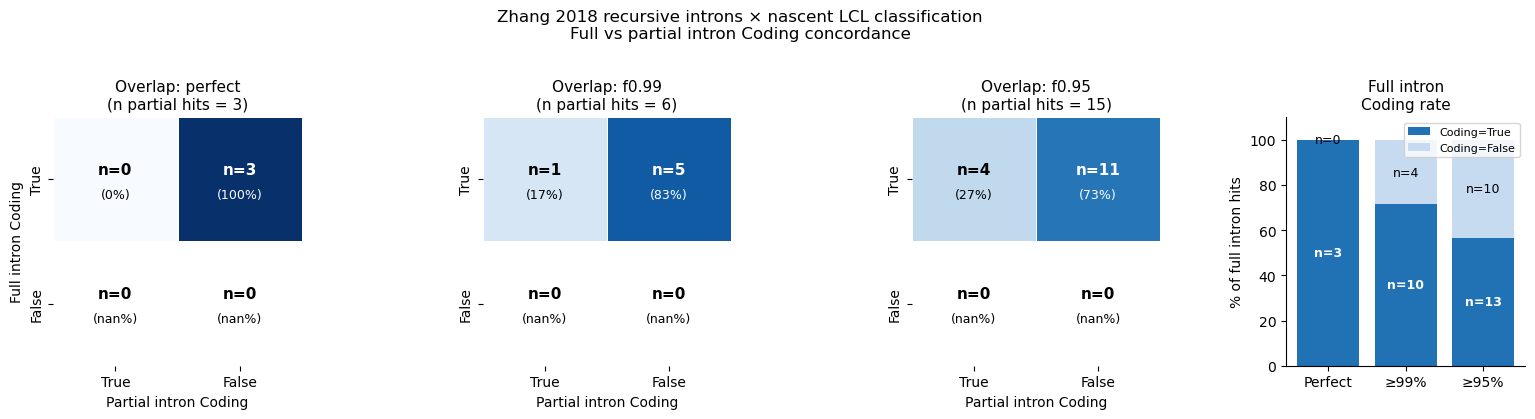

In [15]:
def build_partial_splice_df(res, part_ref, frac_label):
    """Like build_splice_df but for a single threshold; returns one row per partial hit."""
    df_p = res[(frac_label, "Partial")].copy()
    df_p["start"] = df_p["start"].astype(int)
    df_p["end"]   = df_p["end"].astype(int)
    records = []
    for full_id, grp in df_p.groupby("full_intron"):
        chrom_f, coords = full_id.split(":")
        s_f, e_f = (int(x) for x in coords.split("-"))
        full_coding = "N/A"
        for lbl in ("perfect", "f0.99", "f0.95"):
            tmp = res[(lbl, "Full")].copy()
            tmp["start"] = tmp["start"].astype(int)
            tmp["end"]   = tmp["end"].astype(int)
            mf = tmp[(tmp["chrom"] == chrom_f) & (tmp["start"] == s_f) & (tmp["end"] == e_f)]
            if not mf.empty:
                full_coding = mf["Coding"].iloc[0]
                break
        for _, pr in grp.iterrows():
            records.append({
                "partial_coord"  : f"{pr['chrom']}:{pr['start']}-{pr['end']}",
                "full_intron"    : full_id,
                "partial_Coding" : pr["Coding"],
                "full_Coding"    : full_coding,
                "threshold"      : frac_label,
            })
    return pd.DataFrame(records)

thresh_labels = ["perfect", "f0.99", "f0.95"]
all_partial = pd.concat(
    [build_partial_splice_df(results, df_part_ref, lbl) for lbl in thresh_labels],
    ignore_index=True
)

# Full intron Coding=True rates per threshold
full_rates = {}
for lbl in thresh_labels:
    df_f = results[(lbl, "Full")]
    n = len(df_f)
    n_t = (df_f["Coding"] == "True").sum()
    n_f = (df_f["Coding"] == "False").sum()
    full_rates[lbl] = {"Total": n, "Coding=True": n_t, "Coding=False": n_f}

fig, axes = plt.subplots(1, 4, figsize=(16, 4),
                         gridspec_kw={"width_ratios": [3, 3, 3, 2]})

cmap = sns.color_palette("Blues", as_cmap=True)

for ax, lbl in zip(axes[:3], thresh_labels):
    sub = all_partial[all_partial["threshold"] == lbl].copy()
    sub = sub[sub["full_Coding"].isin(["True", "False"])]

    ct = pd.crosstab(sub["full_Coding"], sub["partial_Coding"],
                     rownames=["Full intron\nCoding"],
                     colnames=["Partial intron Coding"])
    # ensure both columns present
    for col in ["True", "False"]:
        if col not in ct.columns:
            ct[col] = 0
    ct = ct[["True", "False"]]
    for idx in ["True", "False"]:
        if idx not in ct.index:
            ct.loc[idx] = 0
    ct = ct.loc[["True", "False"]]

    # row percentages
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

    sns.heatmap(ct_pct, ax=ax, cmap=cmap, vmin=0, vmax=100,
                linewidths=0.5, linecolor="white",
                cbar=False, annot=False, square=True)

    # annotate each cell with count (n=X) and percentage
    for i, row_idx in enumerate(ct.index):
        for j, col_idx in enumerate(ct.columns):
            n_cell = ct.loc[row_idx, col_idx]
            pct    = ct_pct.loc[row_idx, col_idx]
            color  = "white" if pct > 60 else "black"
            ax.text(j + 0.5, i + 0.42, f"n={n_cell}",
                    ha="center", va="center", fontsize=11, color=color, fontweight="bold")
            ax.text(j + 0.5, i + 0.62, f"({pct:.0f}%)",
                    ha="center", va="center", fontsize=9, color=color)

    ax.set_title(f"Overlap: {lbl}\n(n partial hits = {len(sub)})", fontsize=11)
    ax.set_xlabel("Partial intron Coding", fontsize=10)
    ax.set_ylabel("Full intron Coding" if lbl == "perfect" else "", fontsize=10)

# Right panel: Coding=True rates for Full introns
ax4 = axes[3]
lbl_names = {"perfect": "Perfect", "f0.99": "≥99%", "f0.95": "≥95%"}
x = np.arange(len(thresh_labels))
tots  = [full_rates[l]["Total"]       for l in thresh_labels]
n_t   = [full_rates[l]["Coding=True"] for l in thresh_labels]
n_f   = [full_rates[l]["Coding=False"]for l in thresh_labels]
pct_t = [100 * nt / tot if tot else 0 for nt, tot in zip(n_t, tots)]

bars_t = ax4.bar(x, pct_t, color="#2171b5", label="Coding=True")
bars_f = ax4.bar(x, [100 - p for p in pct_t], bottom=pct_t,
                 color="#c6dbef", label="Coding=False")

for xi, (nt, nf, tot, pt) in enumerate(zip(n_t, n_f, tots, pct_t)):
    ax4.text(xi, pt / 2,          f"n={nt}", ha="center", va="center",
             fontsize=9, color="white", fontweight="bold")
    ax4.text(xi, pt + (100 - pt) / 2, f"n={nf}", ha="center", va="center",
             fontsize=9, color="black")

ax4.set_xticks(x)
ax4.set_xticklabels([lbl_names[l] for l in thresh_labels])
ax4.set_ylabel("% of full intron hits", fontsize=10)
ax4.set_title("Full intron\nCoding rate", fontsize=11)
ax4.set_ylim(0, 110)
ax4.legend(fontsize=8, loc="upper right")
ax4.spines[["top","right"]].set_visible(False)

fig.suptitle("Zhang 2018 recursive introns × nascent LCL classification\nFull vs partial intron Coding concordance",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("../code/resources/Zhang2018_classification_heatmap.pdf", bbox_inches="tight")
plt.show()

### 9b. Concordance bars: partial intron classification agreement by coverage type

For each overlap threshold, two 100%-stacked bars — one for full introns **without** two-consecutive partial matches, one for those **with** — showing what fraction of their partial introns are all concordant (Coding=True), mixed, or all discordant (Coding=False).

Unit of analysis: unique Coding=True full introns with at least one partial hit.
For each full intron, a partial intron coord is counted as Coding=True if **any** overlapping classification junction is Coding=True.

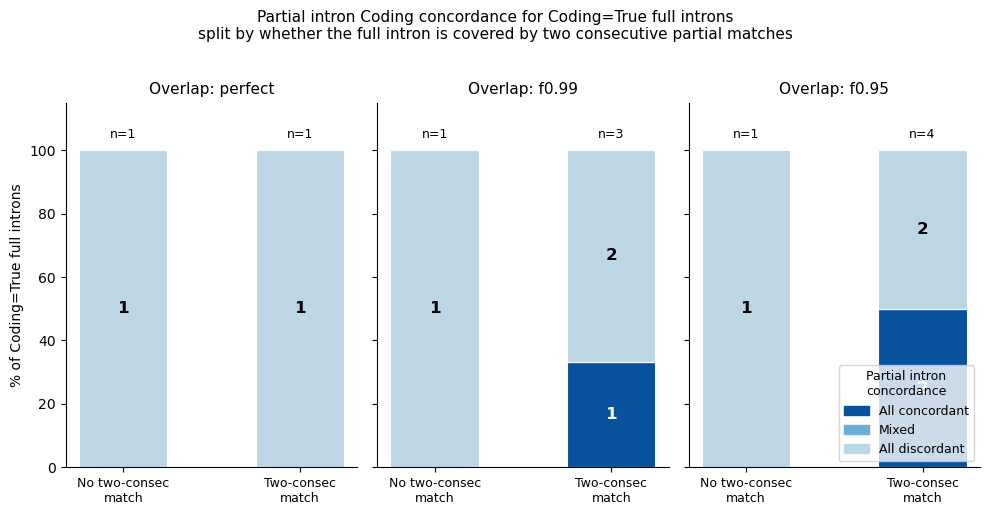

In [16]:
def classify_full_introns(res, thresh_label, cov_map):
    """
    For each unique Coding=True full intron with partial hits at thresh_label,
    determine concordance status of its partial introns and coverage type.
    Returns a DataFrame with one row per unique full intron.
    """
    sub = all_partial[all_partial["threshold"] == thresh_label].copy()
    sub = sub[sub["full_Coding"] == "True"]
    if sub.empty:
        return pd.DataFrame()

    # For each (full_intron, partial_coord): Coding=True if ANY hit is True
    dedup = (sub.groupby(["full_intron", "partial_coord"])["partial_Coding"]
               .apply(lambda x: "True" if "True" in x.values else "False")
               .reset_index())

    records = []
    for full_id, fg in dedup.groupby("full_intron"):
        coding_vals = fg["partial_Coding"].values
        n_true  = (coding_vals == "True").sum()
        n_total = len(coding_vals)
        if n_true == n_total:
            status = "All concordant"
        elif n_true == 0:
            status = "All discordant"
        else:
            status = "Mixed"
        ctype = cov_map.get(full_id, "other")
        records.append({"full_intron": full_id, "status": status,
                        "coverage_type": ctype, "n_partial": n_total,
                        "n_coding": n_true})
    return pd.DataFrame(records)


status_order  = ["All concordant", "Mixed", "All discordant"]
status_colors = {"All concordant": "#08519c",
                 "Mixed":          "#6baed6",
                 "All discordant": "#bdd7e7"}
ctype_order   = ["other", "two_consec"]
ctype_labels  = {"other":      "No two-consec\nmatch",
                 "two_consec": "Two-consec\nmatch"}

fig, axes = plt.subplots(1, 3, figsize=(10, 5), sharey=True)

for ax, lbl in zip(axes, thresh_labels):
    full_df = classify_full_introns(results, lbl, cov_map)

    x = np.arange(len(ctype_order))
    bottoms = np.zeros(len(ctype_order))

    for status in status_order:
        heights_abs = np.array([
            ((full_df["coverage_type"] == g) & (full_df["status"] == status)).sum()
            if not full_df.empty else 0
            for g in ctype_order
        ])
        totals = np.array([
            (full_df["coverage_type"] == g).sum() if not full_df.empty else 0
            for g in ctype_order
        ])
        heights_pct = np.where(totals > 0, 100.0 * heights_abs / totals, 0.0)

        bars = ax.bar(x, heights_pct, bottom=bottoms,
                      color=status_colors[status], label=status,
                      width=0.5, edgecolor="white", linewidth=0.8)

        for i, (h, b, n) in enumerate(zip(heights_pct, bottoms, heights_abs)):
            if h > 4 and n > 0:
                txt_color = "white" if status == "All concordant" else "black"
                ax.text(i, b + h / 2, str(int(n)),
                        ha="center", va="center", fontsize=12,
                        fontweight="bold", color=txt_color)

        bottoms = bottoms + heights_pct

    # Total n above each bar
    for i, g in enumerate(ctype_order):
        tot = (full_df["coverage_type"] == g).sum() if not full_df.empty else 0
        ax.text(i, 103, f"n={tot}", ha="center", va="bottom", fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels([ctype_labels[g] for g in ctype_order], fontsize=9)
    ax.set_title(f"Overlap: {lbl}", fontsize=11)
    ax.set_ylim(0, 115)
    ax.spines[["top", "right"]].set_visible(False)
    if ax is axes[0]:
        ax.set_ylabel("% of Coding=True full introns", fontsize=10)

# Shared legend
handles = [mpatches.Patch(color=status_colors[s], label=s) for s in status_order]
axes[-1].legend(handles=handles, fontsize=9, loc="lower right",
                title="Partial intron\nconcordance", title_fontsize=9)

fig.suptitle(
    "Partial intron Coding concordance for Coding=True full introns\n"
    "split by whether the full intron is covered by two consecutive partial matches",
    fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig("../code/resources/Zhang2018_concordance_bars.pdf", bbox_inches="tight")
plt.show()

## 10. Overall misclassification rate due to recursive splicing

Of the 836,516 junctions in the nascent LCL classification, how many are partial introns from Zhang 2018 recursive splicing events, and what fraction are "misclassified" (Coding=False when the parent full intron is Coding=True)?

In [17]:
total_junctions = len(df_classif)

# Use f0.95 as the broadest threshold (most inclusive)
df_p95_partial = all_partial[all_partial["threshold"] == "f0.95"].copy()

# Unique partial intron coords detected at f0.95
n_partial_detected = df_p95_partial["partial_coord"].nunique()

# Misclassified: partial=False but full=True (unique partial coords)
misclass = df_p95_partial[
    (df_p95_partial["partial_Coding"] == "False") &
    (df_p95_partial["full_Coding"]    == "True")
]["partial_coord"].nunique()

# Also: partial introns from non-coding full introns that weren't detected at all
# (their Coding=False by absence, but full=False too — not a misclassification)
n_full_hits_f95 = df_p95_partial["full_intron"].nunique()
n_full_introns_zhang = df_full_ref["chrom"].count()  # total rows (some duplicated for alt partials)
n_full_unique = df_full_ref_cov["full_id"].nunique()

print(f"Total junctions in nascent LCL classification : {total_junctions:,}")
print(f"Total unique full introns in Zhang 2018       : {n_full_unique:,}")
print(f"Partial introns detected at ≥95% overlap      : {n_partial_detected:,}  unique coords")
print(f"  of which: full_Coding=True, partial=False   : {misclass:,}  (misclassified due to recursive splicing)")
print()
print(f"Misclassified junctions / total junctions     : {misclass}/{total_junctions:,} = {100*misclass/total_junctions:.4f}%")
print()
print("Note: the 'perfect' overlap threshold gives a lower bound on exact matches.")
# Perfect overlap misclass
perf = all_partial[all_partial["threshold"] == "perfect"]
perf_miss = perf[
    (perf["partial_Coding"] == "False") & (perf["full_Coding"] == "True")
]["partial_coord"].nunique()
print(f"At perfect overlap: {perf_miss} misclassified unique partial intron(s)")

Total junctions in nascent LCL classification : 836,516
Total unique full introns in Zhang 2018       : 327
Partial introns detected at ≥95% overlap      : 15  unique coords
  of which: full_Coding=True, partial=False   : 8  (misclassified due to recursive splicing)

Misclassified junctions / total junctions     : 8/836,516 = 0.0010%

Note: the 'perfect' overlap threshold gives a lower bound on exact matches.
At perfect overlap: 3 misclassified unique partial intron(s)


## 11. Coordinate offset sweep: Zhang full introns vs LCL classification

Try every combination of start-offset and end-offset in [-3, +3] to find which shift (if any)
best aligns Zhang 2018 full intron coordinates with the LCL classification junctions.
A match requires `chrom`, `start+ds`, and `end+de` to all be identical.

In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import gzip

# ── Load Zhang full introns ──────────────────────────────────────────────────
full_cols = ['chrom','start','end','gene','score','strand','partial1','partial2']
df_zhang = pd.read_csv("../code/resources/Zhang_2018_full_introns.sorted.bed.gz",
                       sep='\t', header=None, names=full_cols)
df_zhang['start'] = df_zhang['start'].astype(int)
df_zhang['end']   = df_zhang['end'].astype(int)
df_zhang = df_zhang.drop_duplicates(['chrom','start','end'])
print(f"Zhang unique full introns: {len(df_zhang)}")

# ── Load LCL classification (keep only chrom/start/end/Coding) ───────────────
lcl_cols = ['chrom','start','end','gene','dot','strand','Annot','Coding','UTR','GencodePC']
df_lcl = pd.read_csv("../code/resources/nascent_LCL.classification_recursive.bed.gz",
                     sep='\t', header=None, names=lcl_cols, compression='gzip',
                     usecols=['chrom','start','end','Coding'])
df_lcl['start'] = df_lcl['start'].astype(int)
df_lcl['end']   = df_lcl['end'].astype(int)
df_lcl = df_lcl.drop_duplicates(['chrom','start','end'])   # one row per unique junction
print(f"LCL unique junctions:      {len(df_lcl):,}")

Zhang unique full introns: 327
LCL unique junctions:      804,428


In [33]:
offsets = range(-3, 4)   # -3 … +3 inclusive

# Result grids: n_junctions matched and n_unique_full_introns matched
grid_junctions = pd.DataFrame(index=offsets, columns=offsets, dtype=int)
grid_introns   = pd.DataFrame(index=offsets, columns=offsets, dtype=int)
# Also store the matched genes for inspection
match_details  = {}

lcl_set = df_lcl.set_index(['chrom','start','end'])['Coding']   # fast lookup

for ds in offsets:
    for de in offsets:
        df_test = df_zhang.copy()
        df_test['s2'] = df_test['start'] + ds
        df_test['e2'] = df_test['end']   + de
        merged = df_test.merge(df_lcl, left_on=['chrom','s2','e2'],
                               right_on=['chrom','start','end'], how='inner')
        grid_junctions.loc[ds, de] = len(merged)
        grid_introns.loc[ds, de]   = merged[['chrom','start_x','end_x']].drop_duplicates().__len__()
        if len(merged) > 0:
            match_details[(ds, de)] = sorted(merged['gene'].unique().tolist())

print("Grid: number of matched rows (Zhang–LCL junction pairs)")
print("      rows = start offset (ds),  cols = end offset (de)")
print(grid_junctions.to_string())
print()
print("Grid: number of unique Zhang full introns matched")
print(grid_introns.to_string())

Grid: number of matched rows (Zhang–LCL junction pairs)
      rows = start offset (ds),  cols = end offset (de)
     -3   -2   -1   0    1    2    3 
-3  0.0  0.0  0.0  0.0  0.0  0.0  0.0
-2  0.0  0.0  0.0  0.0  0.0  0.0  0.0
-1  0.0  0.0  0.0  0.0  0.0  0.0  0.0
0   0.0  0.0  0.0  2.0  0.0  0.0  0.0
1   0.0  0.0  0.0  0.0  3.0  0.0  0.0
2   0.0  0.0  0.0  0.0  0.0  1.0  0.0
3   0.0  0.0  0.0  0.0  0.0  0.0  0.0

Grid: number of unique Zhang full introns matched
     -3   -2   -1   0    1    2    3 
-3  0.0  0.0  0.0  0.0  0.0  0.0  0.0
-2  0.0  0.0  0.0  0.0  0.0  0.0  0.0
-1  0.0  0.0  0.0  0.0  0.0  0.0  0.0
0   0.0  0.0  0.0  2.0  0.0  0.0  0.0
1   0.0  0.0  0.0  0.0  3.0  0.0  0.0
2   0.0  0.0  0.0  0.0  0.0  1.0  0.0
3   0.0  0.0  0.0  0.0  0.0  0.0  0.0


In [36]:
lcl_set

chrom  start      end      
chr1   944800     945056       True
                  945041       True
       944819     945056       True
                  945041       True
       945146     945517       True
                               ... 
chrY   156023213  156023301    True
       156023460  156024119    True
       156024272  156025031    True
       156025049  156025240    True
       156025100  156025240    True
Name: Coding, Length: 804428, dtype: bool

In [37]:
df_zhang

,chrom,start,end,gene,score,strand,partial1,partial2
0,chr1,14099683,14142921,PRDM2,12.954081,+,chr1:14099683-14108945,chr1:14108945-14142921
1,chr1,19712120,19746154,CAPZB,10.870653,-,chr1:19712120-19733027,chr1:19733027-19746154
2,chr1,26772923,26784281,DHDDS,5.152871,+,chr1:26772923-26781537,chr1:26781537-26784281
3,chr1,27755443,27816496,WASF2,7.977133,-,chr1:27755443-27803478,chr1:27803478-27816496
4,chr1,29391670,29424318,EPB41,6.832171,+,chr1:29391670-29395244,chr1:29395244-29424318
...,...,...,...,...,...,...,...,...
355,chrX,71131217,71351928,NHSL2,12.314702,+,chrX:71131217-71229195,chrX:71229195-71351928
356,chrX,85166343,85211157,CHM,8.993618,-,chrX:85166343-85198147,chrX:85198147-85211157
357,chrX,128682578,128691301,OCRL,8.184103,+,chrX:128682578-128687212,chrX:128687212-128691301
358,chrX,131763121,132090835,HS6ST2,7.202184,-,chrX:131763121-131844168,chrX:131844168-132090835


In [38]:
df_test.merge(df_lcl, left_on=['chrom','s2','e2'],
                               right_on=['chrom','start','end'], how='inner')

,chrom,start_x,end_x,gene,score,strand,partial1,partial2,s2,e2,start_y,end_y,Coding


In [ ]:
# ── Heatmap visualisation ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, grid, title in zip(axes,
                            [grid_junctions, grid_introns],
                            ["Matched rows\n(junction pairs)",
                             "Unique Zhang full introns\nmatched"]):
    g = grid.astype(int)
    sns.heatmap(g, ax=ax, cmap="Blues", annot=True, fmt="d",
                linewidths=0.5, linecolor="white",
                xticklabels=[str(x) for x in offsets],
                yticklabels=[str(x) for x in offsets])
    ax.set_xlabel("End offset  (de)", fontsize=11)
    ax.set_ylabel("Start offset  (ds)", fontsize=11)
    ax.set_title(title, fontsize=12)

fig.suptitle("Zhang 2018 full introns  ×  nascent LCL classification\n"
             "Exact match after applying (ds, de) coordinate offsets",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# ── Print genes for every non-zero cell ──────────────────────────────────────
print("\nNon-zero cells with matched genes:")
for (ds, de), genes in sorted(match_details.items(), key=lambda x: -len(x[1])):
    print(f"  ds={ds:+d}  de={de:+d}  n={len(genes):2d}  {genes}")

In [12]:
(df_full_ref.end.astype(int) - df_full_ref.start.astype(int)).min()

np.int64(5078)